K-Means Clustering

 Activity-10

1. Implement K-Means clusteing technique on Geyser's Eruptions Segmentation and segregate waiting time between eruptions and the duration of the old Faithfull geyser in Yellowstone National Park, Wyoming, USA.

Clustered Data:
     duration  waiting  Cluster
0       3.600       79        1
1       1.800       54        0
2       3.333       74        1
3       2.283       62        0
4       4.533       85        1
..        ...      ...      ...
267     4.117       81        1
268     2.150       46        0
269     4.417       90        1
270     1.817       46        0
271     4.467       74        1

[272 rows x 3 columns]


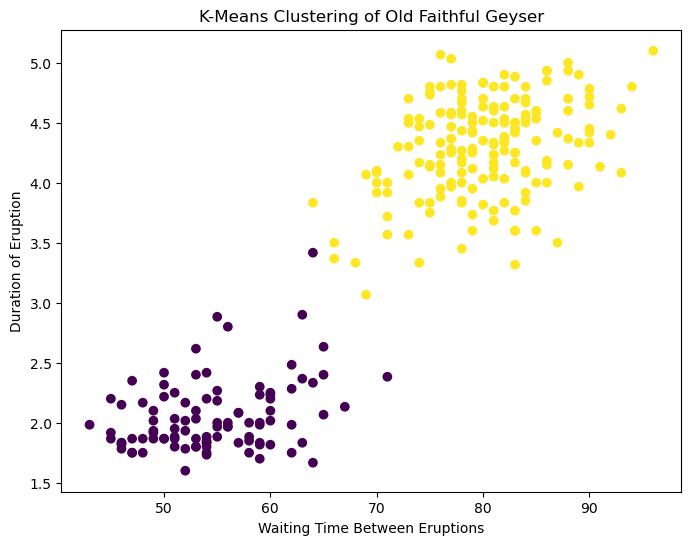

In [1]:
import os
os.environ["OMP_NUM_THREADS"] = "2"

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load dataset
df = pd.read_csv(
    "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/geyser.csv"
)

# Select features
X = df[["waiting", "duration"]]

# Standardize
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# K-Means clustering
kmeans = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

print("Clustered Data:")
print(df[["duration", "waiting", "Cluster"]])

# Plot
plt.figure(figsize=(8, 6))

plt.scatter(
    df["waiting"],
    df["duration"],
    c=df["Cluster"]
)

plt.xlabel("Waiting Time Between Eruptions")
plt.ylabel("Duration of Eruption")
plt.title("K-Means Clustering of Old Faithful Geyser")
plt.show()

Using K-Means clustering compress any image of size 396 x 396 x 3.

Original Image Shape: (592, 518, 3)
Resized Image Shape: (396, 396, 3)


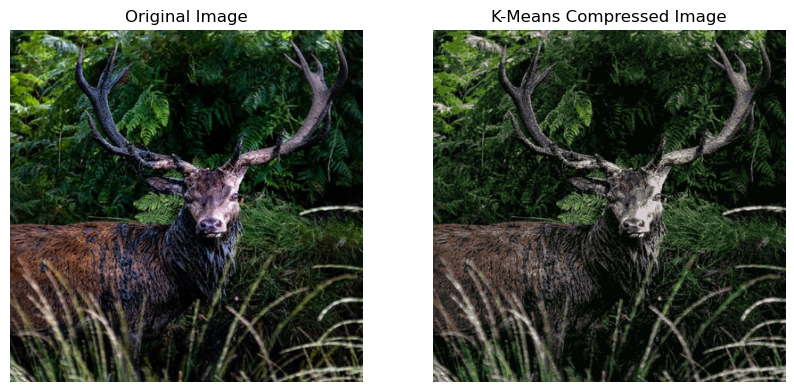

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.cluster import KMeans

# Load image
image = Image.open("image.jpg").convert("RGB")

# Check original size
original_array = np.array(image)
print("Original Image Shape:", original_array.shape)

# Resize image to 396 × 396
image = image.resize((396, 396))

# Convert resized image to array
image_array = np.array(image)

print("Resized Image Shape:", image_array.shape)

# Convert pixels into rows
pixels = image_array.reshape(-1, 3)

# Apply K-Means clustering
kmeans = KMeans(
    n_clusters=16,
    random_state=42,
    n_init=10
)

kmeans.fit(pixels)

# Replace each pixel with its cluster-center color
compressed_pixels = kmeans.cluster_centers_[kmeans.labels_]

# Convert back to image
compressed_image = compressed_pixels.reshape(396, 396, 3)
compressed_image = np.uint8(compressed_image)

# Display original and compressed images
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(image_array)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(compressed_image)
plt.title("K-Means Compressed Image")
plt.axis("off")

plt.show()